# Synthetic Library: Full Example

This notebook demonstrates the core capabilities of the Synthetic library:
1. **Model Creation** - Building hierarchical signaling networks with drugs
2. **Network Topology Visualization** - Visualizing regulatory relationships
3. **Timecourse Simulation** - Simulating ODE dynamics
4. **Synthetic Data Generation** - Creating ML-ready datasets
5. **Data Analysis** - Feature correlations and outcome distributions

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from synthetic import Builder, make_dataset_drug_response

# Publication-ready figure configuration
FONT_SIZE = 10
MM_TO_INCHES = 1 / 25.4

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['axes.titlesize'] = FONT_SIZE
plt.rcParams['axes.labelsize'] = FONT_SIZE
plt.rcParams['xtick.labelsize'] = FONT_SIZE
plt.rcParams['ytick.labelsize'] = FONT_SIZE
plt.rcParams['legend.fontsize'] = FONT_SIZE
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.major.width'] = 0.8
plt.rcParams['ytick.major.width'] = 0.8
plt.rcParams['xtick.major.size'] = 3
plt.rcParams['ytick.major.size'] = 3

# Create a hierarchical network with 3 degrees
vc = Builder.specify(
    degree_cascades=[2, 3, 4],
    random_seed=42,
    auto_drug=True
)

vc.compile()

print(f"Model created with {len(vc.spec.species_list)} species")
print(f"Drug: {vc.list_drugs()[0]['name']}")

Model created with 20 species
Drug: D


## Network Topology Visualization

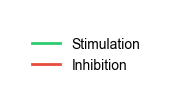

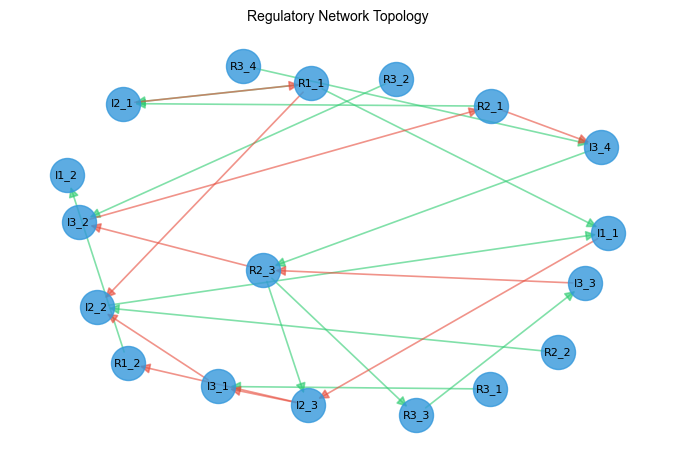

C:\Users\l8105\AppData\Local\Temp\ipykernel_30896\2615805014.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  legend_fig.show()


In [2]:
spec = vc.spec
G = nx.DiGraph()

core_species = [s for s in spec.species_list if not s.startswith('D') and s not in ['O', 'Oa']]
for s in core_species:
    G.add_node(s)

for reg in spec.regulations:
    if reg.from_specie in core_species and reg.to_specie in core_species:
        color = '#2ecc71' if reg.reg_type == 'up' else '#e74c3c'
        G.add_edge(reg.from_specie, reg.to_specie, color=color)

fig_width_mm = 174
fig_height_mm = 120
fig, ax = plt.subplots(figsize=(fig_width_mm * MM_TO_INCHES, fig_height_mm * MM_TO_INCHES))

pos = nx.spring_layout(G, k=2, seed=42)

for reg_type, color in [('up', '#2ecc71'), ('down', '#e74c3c')]:
    edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('color') == color]
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=color,
                           arrowsize=15, width=1.2, alpha=0.6)

nx.draw_networkx_nodes(G, pos, node_color='#3498db', node_size=600, alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=8)

legend_fig, legend_ax = plt.subplots(figsize=(50 * MM_TO_INCHES, 30 * MM_TO_INCHES))
legend_ax.legend(
    handles=[plt.Line2D([0], [0], color='#2ecc71', lw=2, label='Stimulation'),
             plt.Line2D([0], [0], color='#e74c3c', lw=2, label='Inhibition')],
    loc='center',
    frameon=False
)
legend_ax.axis('off')

plt.sca(ax)
plt.title("Regulatory Network Topology")
sns.despine()
plt.axis('off')
plt.tight_layout()
plt.show()

legend_fig.show()

## Timecourse Simulation

In [3]:
from synthetic.Solver.ScipySolver import ScipySolver

antimony = vc.get_antimony()
solver = ScipySolver()
solver.compile(antimony, jit=True)

timecourse = solver.simulate(start=0, stop=10000, step=50)

fig_width_mm = 174
fig_height_mm = 70
fig, axes = plt.subplots(1, 2, figsize=(fig_width_mm * MM_TO_INCHES, fig_height_mm * MM_TO_INCHES))

degree1_species = [s for s in timecourse.columns if s.startswith('R1') or s.startswith('I1')]
colors = plt.cm.tab10(np.linspace(0, 1, len(degree1_species[:5])))
for i, species in enumerate(degree1_species[:5]):
    axes[0].plot(timecourse['time'], timecourse[species], color=colors[i], alpha=0.8, linewidth=1.2)
axes[0].axvline(x=5000, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Degree 1 (Input Layer) Dynamics')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Concentration')
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3, linewidth=0.5)

axes[1].plot(timecourse['time'], timecourse['O'], linewidth=1.5, color='#3498db')
axes[1].plot(timecourse['time'], timecourse['Oa'], linewidth=1.5, color='#e74c3c')
axes[1].axvline(x=5000, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Outcome Dynamics')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Concentration')
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3, linewidth=0.5)

sns.despine()
plt.tight_layout()
plt.show()

legend_fig, legend_ax = plt.subplots(figsize=(40 * MM_TO_INCHES, 25 * MM_TO_INCHES))
legend_ax.legend(
    handles=[plt.Line2D([0], [0], color='#3498db', lw=1.5, label='O (inactive)'),
             plt.Line2D([0], [0], color='#e74c3c', lw=1.5, label='Oa (active)'),
             plt.Line2D([0], [0], color='gray', lw=1, linestyle='--', label='Drug onset')],
    loc='center',
    frameon=False
)
legend_ax.axis('off')
legend_fig.show()

AttributeError: 'VirtualCell' object has no attribute 'get_antimony'

## Synthetic Data Generation

In [ ]:
X, y = make_dataset_drug_response(
    n=500,
    cell_model=vc,
    target_specie='Oa',
    perturbation_type='lognormal',
    perturbation_params={'shape': 0.3}
)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature columns (first 10):\n{list(X.columns[:10])}")
print(f"\nTarget statistics:")
print(y.describe())

## Data Analysis & Visualization

In [ ]:
fig_width_mm = 174
fig_height_mm = 70
fig, axes = plt.subplots(1, 2, figsize=(fig_width_mm * MM_TO_INCHES, fig_height_mm * MM_TO_INCHES))

top_features = X.var().nlargest(12).index
corr_matrix = X[top_features].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Feature Correlation Matrix (Top 12 Variable Features)')
axes[0].tick_params(labelsize=8)

sns.histplot(y, bins=25, kde=True, color='#3498db', ax=axes[1], alpha=0.7)
axes[1].axvline(y.mean(), color='#e74c3c', linestyle='--', linewidth=1.2)
axes[1].set_title('Outcome (Oa) Distribution')
axes[1].set_xlabel('Active Outcome Concentration')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3, linewidth=0.5)

sns.despine()
plt.tight_layout()
plt.show()

## Summary & Quick ML Demo

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipeline = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')

print("=== Synthetic Library Summary ===\n")
print("1. Model Creation: Builder.specify() creates hierarchical networks")
print("2. Network Topology: Access via vc.spec.regulations")
print("3. Timecourse: Use ScipySolver or RoadrunnerSolver")
print("4. Data Generation: make_dataset_drug_response() for sklearn format")
print("\nQuick ML Demo (Ridge Regression, 5-fold CV):")
print(f"  R² scores: {scores}")
print(f"  Mean R²: {scores.mean():.3f} (+/- {scores.std():.3f})")